In [20]:
# BAGGING VS RANDOM FOREST

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification # creates a n class random classification problem
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.tree import plot_tree , DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

In [21]:
x,y = make_classification(n_samples=200,n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

df = pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])
df['target'] = y

df.head(5)

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

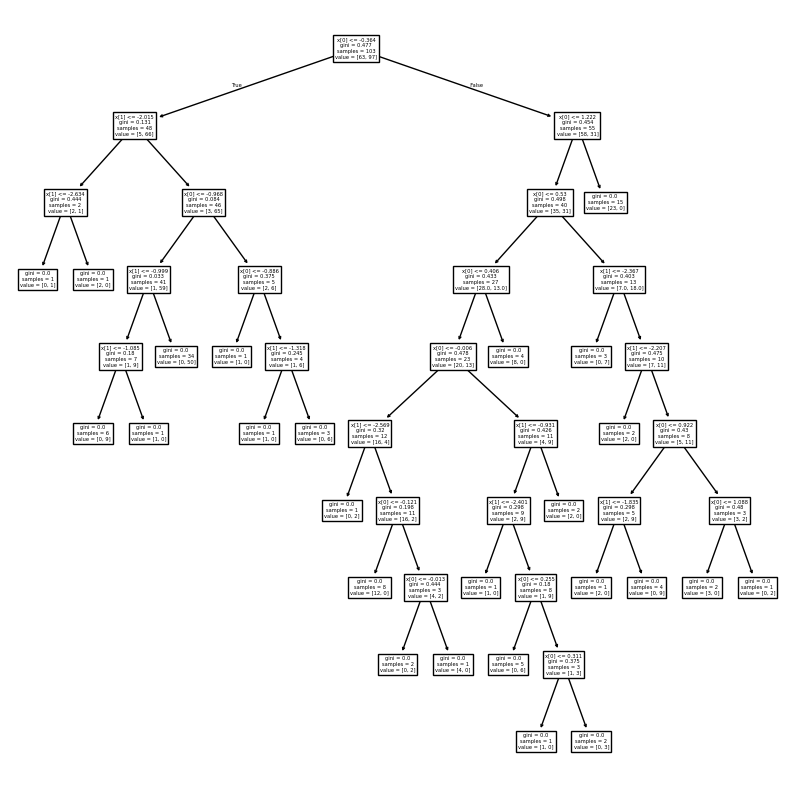

In [22]:
bag = BaggingClassifier(max_features=2)
bag.fit(x_train,y_train)

y_pred_bag = bag.predict(x_test)

plt.figure(figsize=(10,10))
plot_tree(bag.estimators_[0]) # bag.estimators_[0] = first decision tree You are visualizing one tree out of many
plt.show()

# 👉 In Bagging:

# All trees use same features
# Trees become similar

# 👉 In Random Forest:

# Trees see different features
# Trees become diverse

# 👉 Diversity = better results 🎯

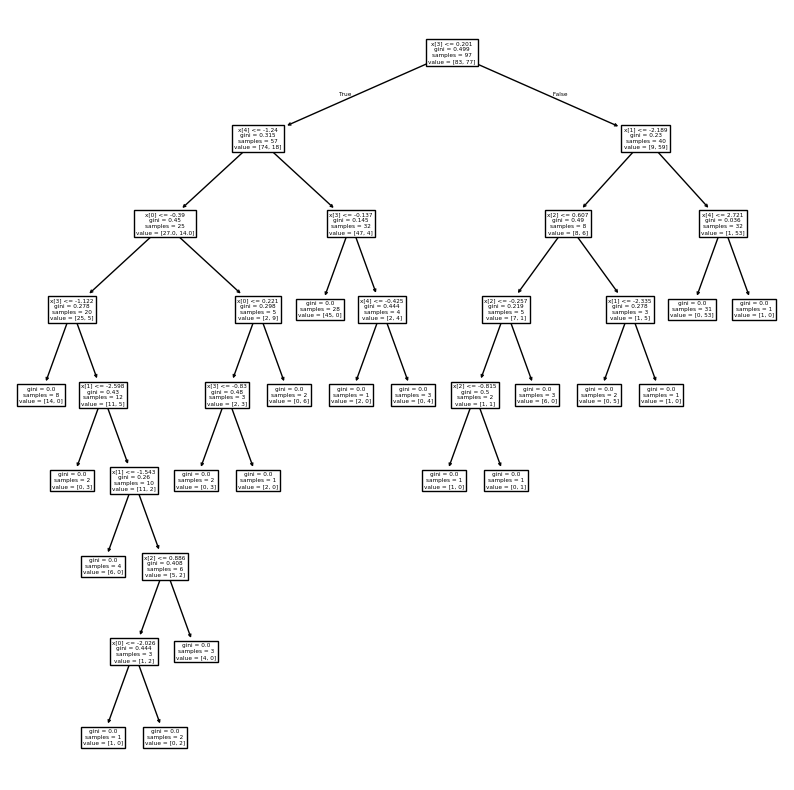

In [23]:
rf = RandomForestClassifier(max_features=2)
rf.fit(x_train,y_train)

y_pred_rf = rf.predict(x_test)

plt.figure(figsize=(10,10))
plot_tree(rf.estimators_[0])
plt.show()

In [26]:
# BAGGING BASICS

a,b = make_classification(n_samples=1000,n_features=10,n_informative=3)
a_train,a_test,b_train,b_test = train_test_split(a,b,test_size=0.2,random_state=42) # random_state is used to control randomness ensures you get the same result every time you run the code

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
a_train_sc = sc.fit_transform(a_train)
a_test_sc = sc.transform(a_test)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(a_train_sc,b_train)
b_pred_dt = dt.predict(a_test_sc)
print("decision tree accuracy score : " , accuracy_score(b_pred_dt,b_test)*100)



decision tree accuracy score :  88.5


In [29]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=500,max_samples=0.5,bootstrap=True,random_state=500,)
bag.fit(a_train_sc,b_train)
b_pred_bag = bag.predict(a_test_sc)
print("bagging accuracy score : " , accuracy_score(b_pred_bag,b_test)*100)

bagging accuracy score :  89.0


In [31]:
bag = BaggingClassifier(estimator=SVC(),n_estimators=500,max_samples=0.5,bootstrap=True,random_state=500,)
bag.fit(a_train_sc,b_train)
b_pred_bag = bag.predict(a_test_sc)
print("bagging using svm accuracy score : " , accuracy_score(b_pred_bag,b_test)*100)

bagging using svm accuracy score :  85.5


In [33]:
# PASTING

pasting = BaggingClassifier(estimator=SVC(),n_estimators=500,max_samples=0.5,bootstrap=False,random_state=500,)
pasting.fit(a_train_sc,b_train)
b_pred_pasting = pasting.predict(a_test_sc)
print("pasting accuracy score : " , accuracy_score(b_pred_pasting,b_test)*100)


pasting accuracy score :  87.0


In [35]:
rf = RandomForestClassifier(max_features=2)
rf.fit(a_train_sc,b_train)
b_pred_rf = rf.predict(a_test_sc)
print("random forest accuracy score : " , accuracy_score(b_pred_rf,b_test)*100)


# random forest is better than bagged models , further bagged models are better than pasting

random forest accuracy score :  90.0


In [18]:
# PROJECT - ENSEMBLE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv('/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# df.head(5)
# df.info()

df.TotalCharges = pd.to_numeric(df.TotalCharges,errors='coerce')
df.dropna(how='any',inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
df.Churn.value_counts()/len(df)*100

X = df.drop(['customerID','Churn'],axis=1)
Y = df.Churn.values

# print(X)
# print(Y)

X = pd.get_dummies(X,columns=['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'],drop_first=True)

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

# ADA BOOST ENSEMBLE
from sklearn.ensemble import AdaBoostClassifier
ad = AdaBoostClassifier(n_estimators = 100)
ad.fit(x_train_sc,y_train)
y_pred_ad = ad.predict(x_test_sc)
print("adaboost accuracy score  : ",accuracy_score(y_pred_ad,y_test)*100)

# GRADIENT ENSEMBLE
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators = 100)
gb.fit(x_train_sc,y_train)
y_pred_gb = gb.predict(x_test_sc)
print("gradient boost accuracy score  : ",accuracy_score(y_pred_gb,y_test)*100)

# EXTREME GRADIENT ENSEMBLE
from xgboost import XGBClassifier
x = XGBClassifier(n_estimators = 100)
x.fit(x_train_sc,y_train)
y_pred_x = x.predict(x_test_sc)
print("extreme gradient boost accuracy score  : ",accuracy_score(y_pred_x,y_test)*100)

adaboost accuracy score  :  79.17555081734187
gradient boost accuracy score  :  78.96233120113718
extreme gradient boost accuracy score  :  77.39872068230277
